In [2]:
pip install pandas matplotlib nltk vaderSentiment wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.8 MB/s eta 0:00:00


Original Reviews:
                                          Review
0   This product is amazing and I really love it
1       The quality of this product is excellent
2               I am very happy with my purchase
3                    This is a fantastic product
4             The service was very good and fast
5            I really enjoyed using this product
6                    The product works perfectly
7                I am satisfied with the quality
8                       This product is terrible
9                            I hate this product
10                             Very poor quality
11                 The service was extremely bad
12          I am disappointed with this purchase
13           The product stopped working quickly
14                           Very bad experience
15            I would not recommend this product
16                           The product is okay
17                        The quality is average
18                    It is neither good nor bad
19

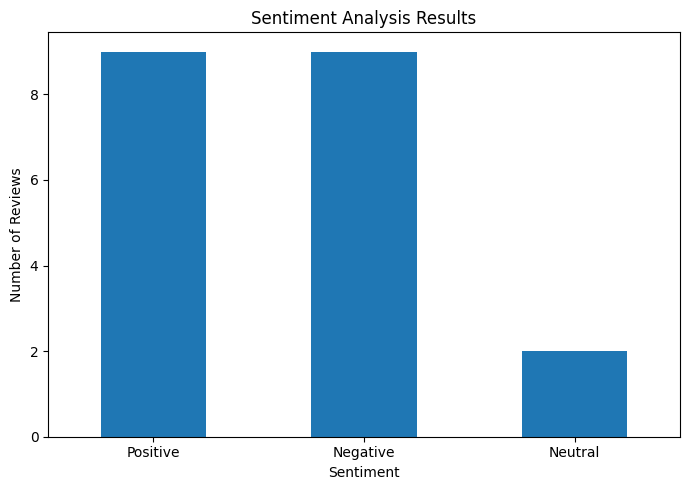

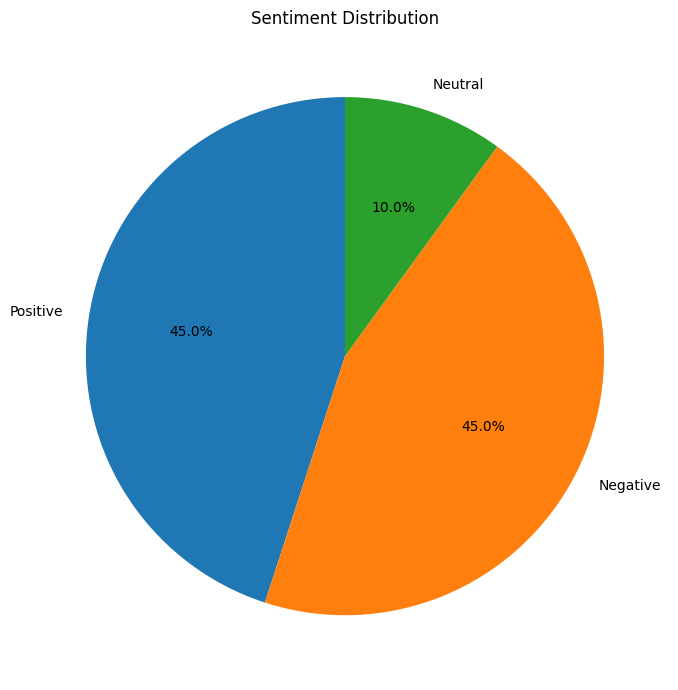

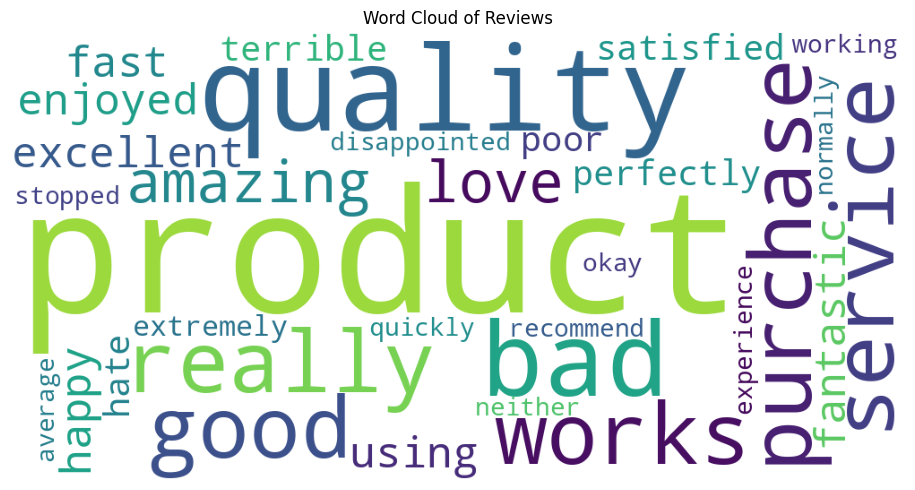


Results saved successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# -----------------------------------------
# 1. Create Text Data
# -----------------------------------------

reviews = [
    "This product is amazing and I really love it",
    "The quality of this product is excellent",
    "I am very happy with my purchase",
    "This is a fantastic product",
    "The service was very good and fast",
    "I really enjoyed using this product",
    "The product works perfectly",
    "I am satisfied with the quality",

    "This product is terrible",
    "I hate this product",
    "Very poor quality",
    "The service was extremely bad",
    "I am disappointed with this purchase",
    "The product stopped working quickly",
    "Very bad experience",
    "I would not recommend this product",

    "The product is okay",
    "The quality is average",
    "It is neither good nor bad",
    "The product works normally"
]

# Create DataFrame
df = pd.DataFrame({
    "Review": reviews
})

print("Original Reviews:")
print(df)

# -----------------------------------------
# 2. Initialize Sentiment Analyzer
# -----------------------------------------

analyzer = SentimentIntensityAnalyzer()

# -----------------------------------------
# 3. Create Sentiment Function
# -----------------------------------------

def analyze_sentiment(text):

    score = analyzer.polarity_scores(text)

    compound = score["compound"]

    if compound >= 0.05:
        sentiment = "Positive"

    elif compound <= -0.05:
        sentiment = "Negative"

    else:
        sentiment = "Neutral"

    return sentiment

# -----------------------------------------
# 4. Apply Sentiment Analysis
# -----------------------------------------

df["Sentiment"] = df["Review"].apply(analyze_sentiment)

# -----------------------------------------
# 5. Display Results
# -----------------------------------------

print("\nSentiment Analysis Results:")
print(df.to_string(index=False))

# -----------------------------------------
# 6. Count Sentiments
# -----------------------------------------

sentiment_count = df["Sentiment"].value_counts()

print("\nSentiment Counts:")
print(sentiment_count)

# -----------------------------------------
# 7. Bar Chart
# -----------------------------------------

plt.figure(figsize=(7, 5))

sentiment_count.plot(kind="bar")

plt.title("Sentiment Analysis Results")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("sentiment_bar_chart.png")

plt.show()

# -----------------------------------------
# 8. Pie Chart
# -----------------------------------------

plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_count,
    labels=sentiment_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Distribution")

plt.tight_layout()

plt.savefig("sentiment_pie_chart.png")

plt.show()

# -----------------------------------------
# 9. Word Cloud
# -----------------------------------------

all_text = " ".join(df["Review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Reviews")

plt.tight_layout()

plt.savefig("wordcloud.png")

plt.show()

# -----------------------------------------
# 10. Save Results
# -----------------------------------------

df.to_csv("sentiment_results.csv", index=False)

print("\nResults saved successfully!")